In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from branca.colormap import linear
from PIL import Image

from estuary.util.img import false_color, true_color

In [3]:
FIG_DIR = Path("/Users/kyledorman/data/estuary/stats_presentation/")

In [4]:
storm_events = pd.read_csv("/Users/kyledorman/data/estuary/geos/storm_events.csv")
storm_events["date_start"] = pd.to_datetime(storm_events["date_start"], errors="coerce")
storm_events["date_end"] = pd.to_datetime(storm_events["date_end"], errors="coerce")
storm_events.head()

,date_start,date_end,event_name,areas_impacted,precipitation_summary
0,2018-01-08,2018-01-09,Montecito Debris Flow Storm,"Santa Barbara County, Ventura County, Los Ange...",Extreme short-burst rainfall; up to ~1.5 in/hr...
1,2018-03-19,2018-03-22,Pineapple Express AR,"Southern California (LA County, Ventura County...",Major moisture plume; widespread heavy rain; d...
2,2019-02-13,2019-02-15,Pineapple Express AR,"San Diego County, Inland Empire, SoCal deserts",Up to 10.1 in (Palomar); 3.7 in in Palm Spring...
3,2020-04-05,2020-04-10,April Cutoff Low + Weak AR,"San Diego County mountains, Transverse Ranges",2-6 in common; >6 in in mountains; flash flooding
4,2021-01-26,2021-01-29,Major AR Event,"SF Bay Area, Santa Cruz Mountains, Monterey/SL...",6-15+ in; highest >15 in in coastal mountains


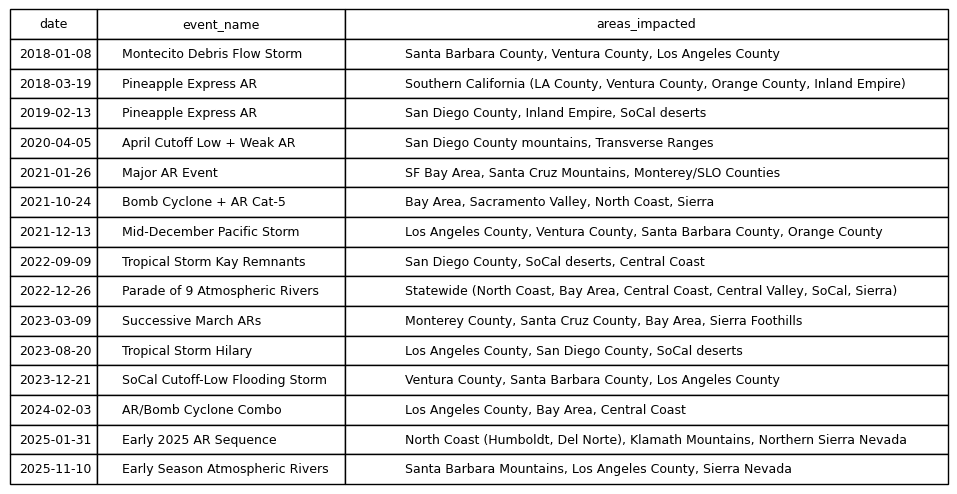

In [6]:
# Create a styled table image using matplotlib
fig, ax = plt.subplots(figsize=(9, 5))
ax.axis("off")
ss_display = (
    storm_events.copy()
    .drop(columns=["precipitation_summary", "date_end"])
    .rename(columns={"date_start": "date"})
)
ss_display["date"] = ss_display.date.dt.date
table = ax.table(
    cellText=ss_display.values, colLabels=ss_display.columns, loc="center", cellLoc="left"
)

table.auto_set_font_size(False)
table.set_fontsize(9)

# Auto-adjust column widths
table.auto_set_column_width(col=list(range(len(storm_events.columns))))

# Scale spacing
table.scale(1, 1.6)

# Save the table image
output_path = FIG_DIR / "storm_events_table.png"
fig.tight_layout()
# plt.savefig(output_path, dpi=200, bbox_inches="tight")

In [7]:
preds_all = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260122-101838/merged_all_regions_timeseries_preds.csv"
)
gdf = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep_usgs.geojson")
skipped_regions = gdf[gdf.skipped]["Site code"]
preds_all["acquired"] = (
    pd.to_datetime(preds_all["acquired"], errors="coerce", utc=True)
    # .dt.tz_convert("UTC")
    # .dt.tz_localize(None)
    # .astype("datetime64[ns]")
)
preds_all["date"] = preds_all.acquired.dt.date
preds_all["month"] = preds_all.acquired.dt.month
preds_all["year"] = preds_all.acquired.dt.year
preds_all = (
    preds_all[
        (~preds_all.region.isin(skipped_regions))
        & (preds_all.y_pred_unsure != 1)
        & (preds_all.year >= 2018)
    ]
    .copy()
    .sort_values(by=["region", "acquired"])
    .reset_index(drop=True)
)
preds_all["openness_01"] = (preds_all["openness"] + 1) / 2

preds_all.head(3)

,region,date,y_true,y_true_unsure,y_pred,y_prob,y_pred_unsure,acquired,source_tif,openness,month,year,openness_01
0,11,2018-01-01,1,0,2,0.999991,False,2018-01-01 17:52:31+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0.999989,1,2018,0.999994
1,11,2018-01-11,1,0,2,0.999961,False,2018-01-11 17:53:00+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0.999979,1,2018,0.999989
2,11,2018-01-13,1,0,2,0.999992,False,2018-01-13 17:53:45+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0.999992,1,2018,0.999996


In [8]:
example_region = 2145

In [9]:
labels = pd.read_csv("/Users/kyledorman/data/estuary/dataset/train.csv")
labels["acquired"] = pd.to_datetime(labels["acquired"], errors="coerce", utc=True)
labels = labels[(~labels.region.isin(skipped_regions))]
print(len(labels))
print(len(labels.region.unique()))

labels.groupby("region").acquired.size().min(), labels.groupby("region").acquired.size().max()

12697
69


(np.int64(99), np.int64(252))

In [10]:
ts_labels = pd.read_csv("/Users/kyledorman/data/estuary/dataset/time_series.csv")
ts_labels["acquired"] = pd.to_datetime(ts_labels["acquired"], errors="coerce", utc=True)
ts_labels = ts_labels[(~ts_labels.region.isin(skipped_regions))]
print(len(ts_labels))
print(len(ts_labels.region.unique()))

ts_labels.groupby("region").acquired.size().min(), ts_labels.groupby("region").acquired.size().max()

10581
7


(np.int64(1272), np.int64(1787))

In [12]:
ss_labels = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat/labels.csv")
ss_labels["acquired"] = pd.to_datetime(ss_labels["acquired"], errors="coerce", utc=True)
ss_labels = ss_labels[(~ss_labels.region.isin(skipped_regions))]
print(len(ss_labels))
print(len(ss_labels.region.unique()))

ss_labels.groupby("region").acquired.size().min(), ss_labels.groupby("region").acquired.size().max()

880
61


(np.int64(1), np.int64(79))

In [20]:
# 1) Make sure date is datetime64[ns]
df = preds_all.copy()
df["date"] = pd.to_datetime(df["date"])

# 2) Get global date range
start = df["date"].min()
end = df["date"].max()

# 3) Build full MultiIndex: all regions × all dates
regions = df["region"].unique()
full_dates = pd.date_range(start, end, freq="D")

full_index = pd.MultiIndex.from_product(
    [regions, full_dates],
    names=["region", "date"],
)

# 4) Reindex and forward-fill within each region
full = df.set_index(["region", "date"]).sort_index().reindex(full_index)

# Forward-fill predictions within each region
full["y_pred"] = full["y_pred"].groupby(level="region").ffill()

# Forward-fill predictions within each region
full["openness_01"] = (
    full["openness_01"]
    .groupby(level="region")
    .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
    .ffill()
    .reset_index(level=0, drop=True)
)

region_min_date = df.groupby("region").date.min().max()
region_max_date = df.groupby("region").date.max().min()

full = full.reset_index()
full = full[full.date.between(region_min_date, region_max_date)].copy()
full = full.set_index(["region", "date"])

# 5) Get a region × time array for IoU
# Rows: region, Cols: date
y_mat = full["y_pred"].unstack("date").astype(int).to_numpy()

y_mat_prob = full["openness_01"].unstack("date").to_numpy()

region_labels = full["y_pred"].unstack("date").index.to_list()

date_axis = full["y_pred"].unstack("date").columns.to_list()

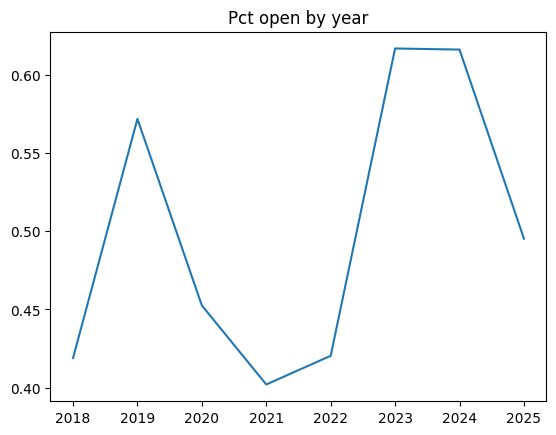

In [24]:
year_pct = []
for year in range(2018, 2026):
    idx = np.array([i for i, d in enumerate(date_axis) if d.year == year])
    pct = y_mat_prob[:, idx].mean()
    year_pct.append(pct)

plt.figure()
plt.plot(list(range(2018, 2026)), year_pct)
_ = plt.title("Pct open by year")

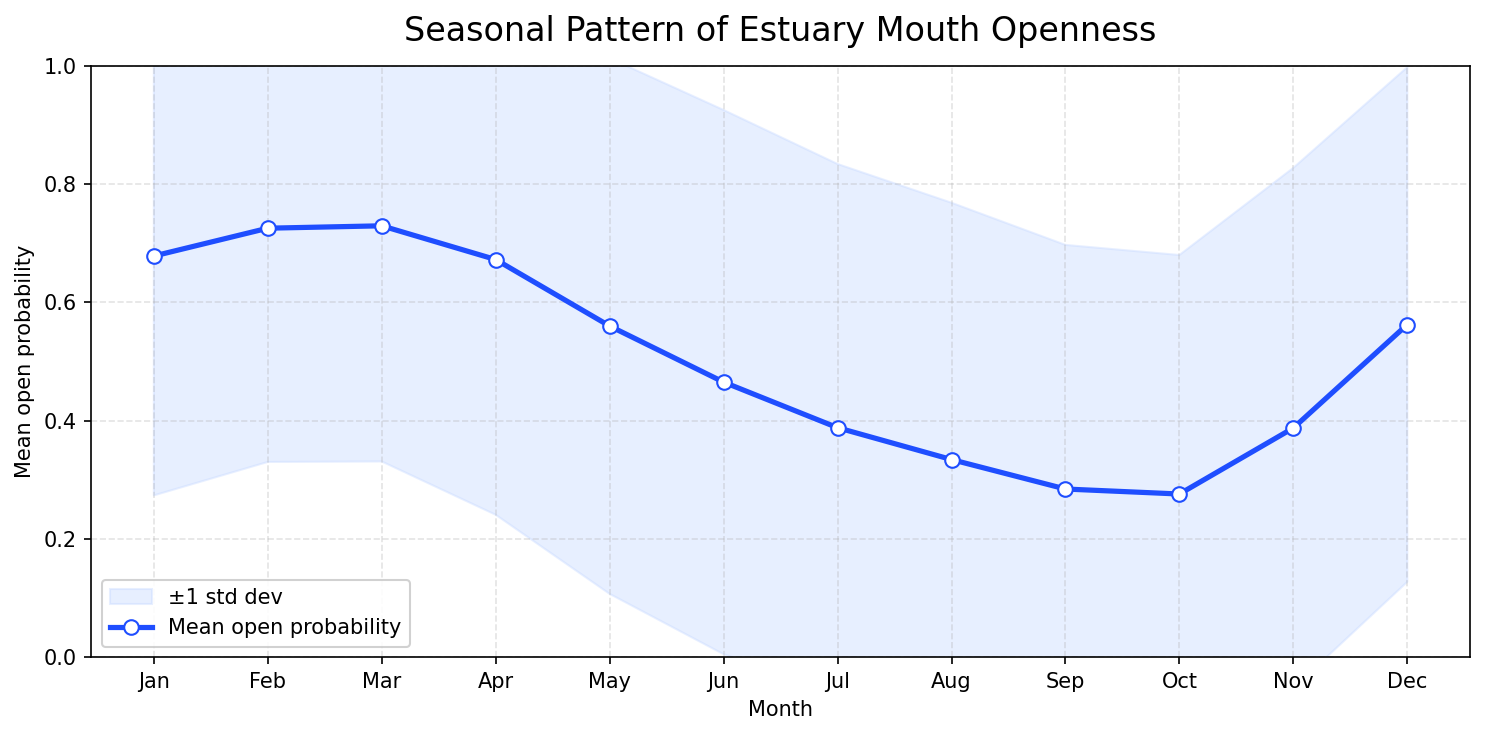

In [26]:
# Compute monthly percent open
month_pct = []
month_pct_std = []  # optional variability shading
for month in range(1, 13):
    idx = np.array([i for i, d in enumerate(date_axis) if d.month == month])
    vals = y_mat_prob[:, idx]
    month_pct.append(vals.mean())
    month_pct_std.append(vals.std())

months = np.arange(1, 13)

plt.figure(figsize=(10, 5), dpi=150)

# Shaded variability
plt.fill_between(
    months,
    np.array(month_pct) - np.array(month_pct_std),
    np.array(month_pct) + np.array(month_pct_std),
    color="#c5d8ff",
    alpha=0.4,
    label="±1 std dev",
)

# Line for monthly mean
plt.plot(
    months,
    month_pct,
    color="#1f4eff",
    linewidth=2.5,
    marker="o",
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="#1f4eff",
    label="Mean open probability",
)

# Fancy x-axis labels
plt.xticks(
    months, ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.ylabel("Mean open probability")
plt.xlabel("Month")
plt.title("Seasonal Pattern of Estuary Mouth Openness", fontsize=16, pad=12)

plt.grid(True, linestyle="--", alpha=0.35)
plt.ylim(0, 1)

plt.legend(frameon=True, facecolor="white", framealpha=0.9)

plt.tight_layout()

# plt.savefig(FIG_DIR / "pct_open_month.png")

plt.show()

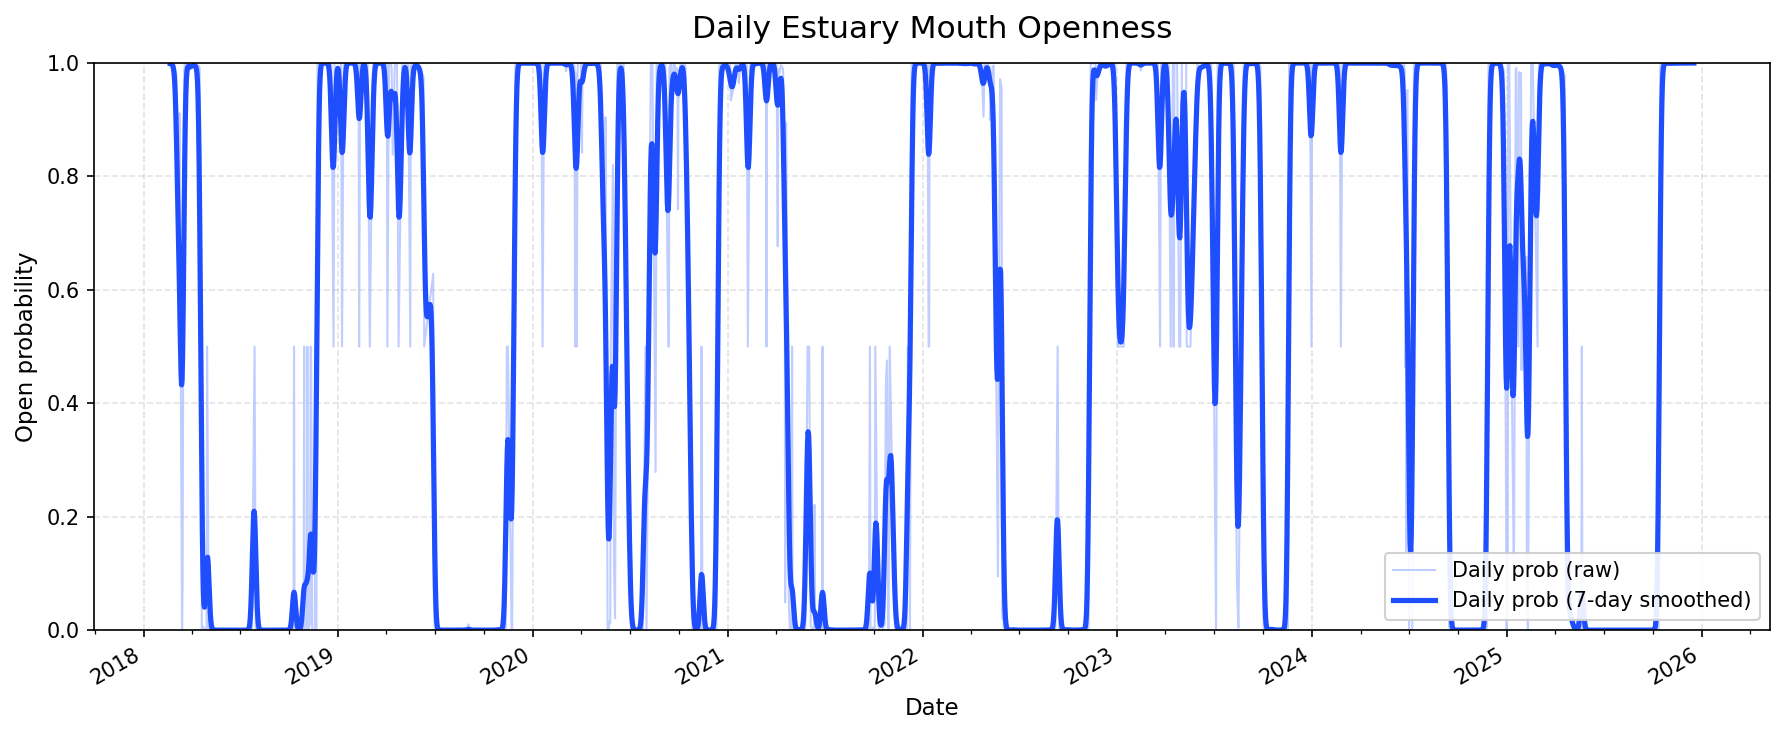

In [28]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# ---------------------------------------------------------
# 1. Prepare daily mean / std from y_mat_prob
# ---------------------------------------------------------
# date_axis: sequence of daily dates aligned with columns of y_mat_prob
dates = pd.to_datetime(date_axis)
assert y_mat_prob.shape[1] == len(dates), "y_mat_prob and date_axis length mismatch"

idx = np.where(np.array(region_labels) == example_region)[0].item()

# Mean and std across regions for each day
daily_prob = y_mat_prob[idx]

# ---------------------------------------------------------
# 2. Smooth with ~7-day Gaussian window
# ---------------------------------------------------------
# Gaussian sigma is in “index units”; sigma≈3 gives you a ~7-day FWHM-ish window.
sigma = 3  # ~weekly smoothing
daily_prob_smooth = gaussian_filter1d(daily_prob, sigma=sigma)

plot_start = pd.to_datetime(dates.min())
plot_end = pd.to_datetime(dates.max())

# ---------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

# Raw daily mean (thin, light)
ax.plot(
    dates,
    daily_prob,
    color="#a6b9ff",
    linewidth=1.0,
    alpha=0.7,
    label="Daily prob (raw)",
)

# Smoothed daily mean (thick, on top)
ax.plot(
    dates,
    daily_prob_smooth,
    color="#1f4eff",
    linewidth=2.5,
    label="Daily prob (7-day smoothed)",
)

# ---------------------------------------------------------
# 6. Cosmetics & formatting
# ---------------------------------------------------------
ax.set_ylabel("Open probability", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.set_title("Daily Estuary Mouth Openness", fontsize=15, pad=12)

ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.35)

# Date formatting on x-axis
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.legend(
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="#cccccc",
)

plt.tight_layout()
# plt.savefig(FIG_DIR / f"{example_region}_timeseries_open_pct.png")
plt.show()

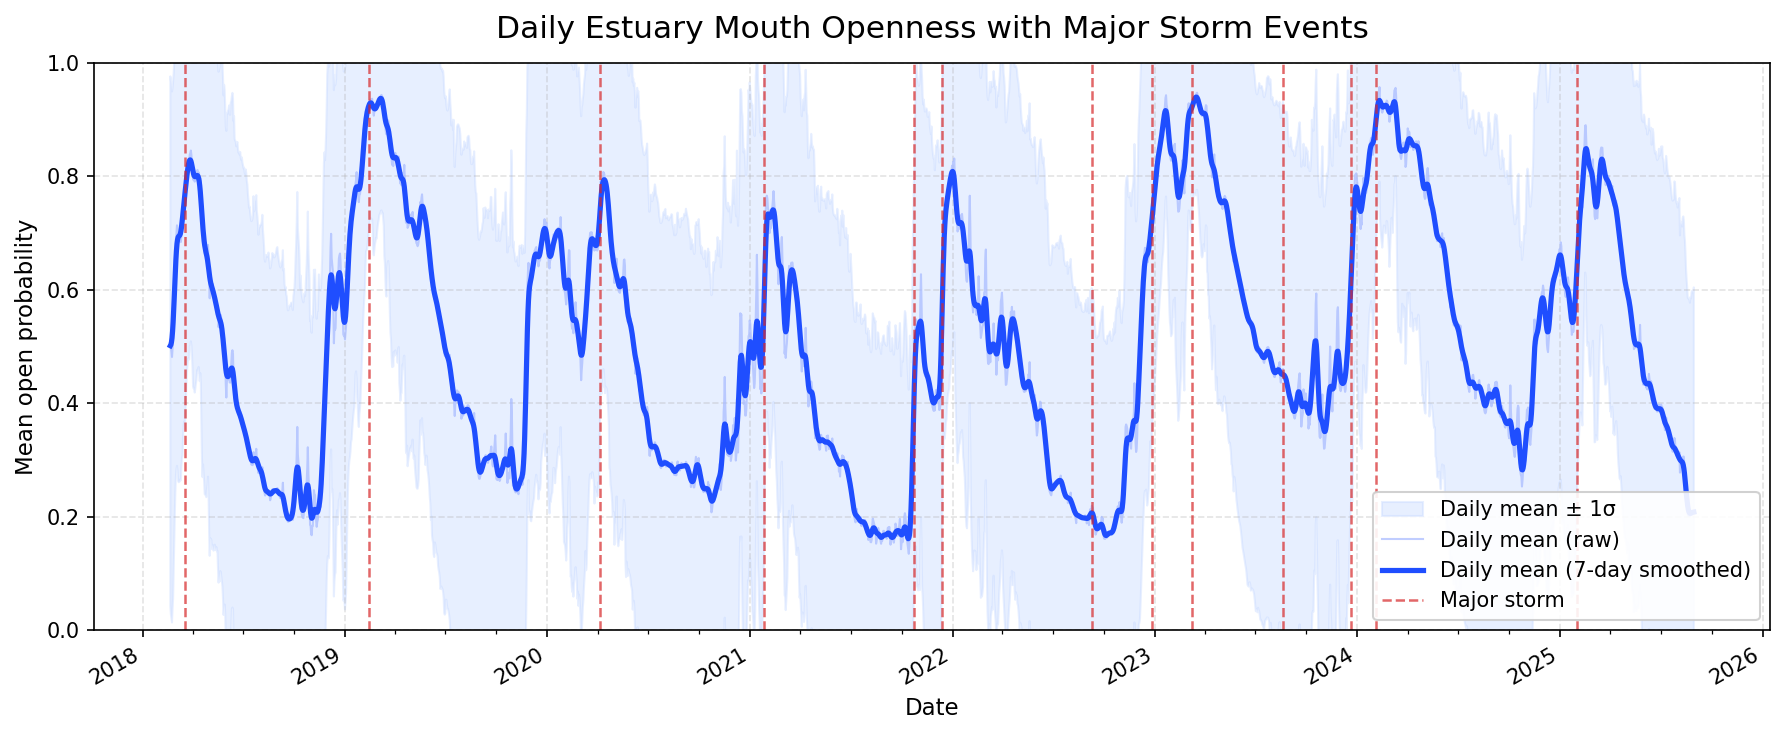

In [24]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# ---------------------------------------------------------
# 1. Prepare daily mean / std from y_mat_prob
# ---------------------------------------------------------
# date_axis: sequence of daily dates aligned with columns of y_mat_prob
dates = pd.to_datetime(date_axis)
assert y_mat_prob.shape[1] == len(dates), "y_mat_prob and date_axis length mismatch"

# Mean and std across regions for each day
daily_mean = y_mat_prob.mean(axis=0)  # shape (n_days,)
daily_std = y_mat_prob.std(axis=0)  # optional shading

# ---------------------------------------------------------
# 2. Smooth with ~7-day Gaussian window
# ---------------------------------------------------------
# Gaussian sigma is in “index units”; sigma≈3 gives you a ~7-day FWHM-ish window.
sigma = 3  # ~weekly smoothing
daily_mean_smooth = gaussian_filter1d(daily_mean, sigma=sigma)

# ---------------------------------------------------------
# 3. Prepare storm events
# ---------------------------------------------------------
storm_events = storm_events.copy()
storm_events["date_start"] = pd.to_datetime(storm_events["date_start"])
storm_events["date_end"] = pd.to_datetime(storm_events["date_end"])

# If they are tz-aware, drop the timezone
if storm_events["date_start"].dt.tz is not None:
    storm_events["date_start"] = storm_events["date_start"].dt.tz_convert(None)
    storm_events["date_end"] = storm_events["date_end"].dt.tz_convert(None)

plot_start = pd.to_datetime(dates.min())
plot_end = pd.to_datetime(dates.max())

storm_mask = (storm_events["date_start"] >= plot_start) & (storm_events["date_start"] <= plot_end)
storm_events_plot = storm_events[storm_mask].sort_values("date_start")

# ---------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

# Shaded ±1 std dev band (raw daily variability)
ax.fill_between(
    dates,
    daily_mean - daily_std,
    daily_mean + daily_std,
    color="#c5d8ff",
    alpha=0.4,
    label="Daily mean ± 1σ",
)

# Raw daily mean (thin, light)
ax.plot(
    dates,
    daily_mean,
    color="#a6b9ff",
    linewidth=1.0,
    alpha=0.7,
    label="Daily mean (raw)",
)

# Smoothed daily mean (thick, on top)
ax.plot(
    dates,
    daily_mean_smooth,
    color="#1f4eff",
    linewidth=2.5,
    label="Daily mean (7-day smoothed)",
)

# ---------------------------------------------------------
# 5. Overlay storm dates
# ---------------------------------------------------------
first_line = True
for _, row in storm_events_plot.iterrows():
    d = row["date_start"]
    ax.axvline(
        d,
        color="#d62728",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        label="Major storm" if first_line else None,
    )
    first_line = False

# ---------------------------------------------------------
# 6. Cosmetics & formatting
# ---------------------------------------------------------
ax.set_ylabel("Mean open probability", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.set_title("Daily Estuary Mouth Openness with Major Storm Events", fontsize=15, pad=12)

ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.35)

# Date formatting on x-axis
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

ax.legend(
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="#cccccc",
)

plt.tight_layout()
plt.savefig(FIG_DIR / "daily_open_pct.png")
plt.show()

In [26]:
import numpy as np
import pandas as pd


def add_season_fields(dates: pd.DatetimeIndex, season_year_mode="djf_to_next_year"):
    """
    season: DJF/MAM/JJA/SON
    season_year_mode:
      - "djf_to_next_year": DJF is labeled by the year of Jan/Feb (e.g., Dec 2020 -> season_year 2021)
      - "calendar": all seasons labeled by calendar year of the timestamp
    """
    m = dates.month
    season = np.where(
        m.isin([12, 1, 2]),
        "DJF",
        np.where(m.isin([3, 4, 5]), "MAM", np.where(m.isin([6, 7, 8]), "JJA", "SON")),
    )

    if season_year_mode == "calendar":
        season_year = dates.year
    elif season_year_mode == "djf_to_next_year":
        # Dec counts toward next year's DJF
        season_year = dates.year + (m == 12).astype(int)
    else:
        raise ValueError("season_year_mode must be 'djf_to_next_year' or 'calendar'")

    return season, season_year


def add_water_year_fields(dates: pd.DatetimeIndex, start_month=10, label="end"):
    """
    Water year (default Oct-Sep). If label='end', WY 2021 = Oct 2020 .. Sep 2021.
    """
    y = dates.year
    m = dates.month
    if label == "end":
        wy = y + (m >= start_month).astype(int)
    elif label == "start":
        wy = y - (m < start_month).astype(int)
    else:
        raise ValueError("label must be 'end' or 'start'")
    return wy


def aggregate_region_time(
    full: pd.DataFrame,
    value_col="y_prob",
    how="D",
    agg="mean",
    week_ends="SUN",
    season_year_mode="djf_to_next_year",
    water_year_start_month=10,
    water_year_label="end",
):
    """
    full: DataFrame indexed by ['region','date'] with a column value_col.
    how:
      - 'D' (daily / no aggregation)
      - 'W' (weekly)
      - 'M' (monthly)
      - 'Y' (calendar year)
      - 'WY' (water year)
      - 'S' (meteorological season: DJF/MAM/JJA/SON)
    Returns:
      mat: (n_regions, n_bins) float array
      regions: index labels for rows
      time_bins: labels for columns (PeriodIndex-ish or tuples)
      wide_df: DataFrame region x bin (for debugging / plotting)
    """
    df = full.reset_index()[["region", "date", value_col]].copy()
    df["date"] = pd.to_datetime(df["date"])

    regions = pd.Index(df["region"].unique(), name="region")

    if how == "D":
        # treat each day as a bin (still do a pivot)
        df["bin"] = df["date"]
    elif how == "W":
        # weekly bins, choose week ending day
        rule = f"W-{week_ends.upper()}"
        df["bin"] = df["date"].dt.to_period(rule)
    elif how == "M":
        df["bin"] = df["date"].dt.to_period("M")
    elif how == "Y":
        df["bin"] = df["date"].dt.to_period("Y")
    elif how == "WY":
        wy = add_water_year_fields(
            df["date"].dt.to_pydatetime().__class__(df["date"]),  # robust-ish
            start_month=water_year_start_month,
            label=water_year_label,
        )
        # easier: vectorized via numpy on datetime64
        dates = pd.DatetimeIndex(df["date"].values)
        wy = add_water_year_fields(
            dates, start_month=water_year_start_month, label=water_year_label
        )
        df["bin"] = wy.astype(int)
    elif how == "S":
        dates = pd.DatetimeIndex(df["date"].values)
        season, season_year = add_season_fields(dates, season_year_mode=season_year_mode)
        df["bin"] = list(zip(season_year.astype(int), season))  # (year, 'DJF'/'MAM'...)
    else:
        raise ValueError("how must be one of: 'D','W','M','Y','WY','S'")

    # aggregate within each (region, bin)
    grouped = df.groupby(["region", "bin"], sort=True)[value_col].agg(agg).reset_index()

    # pivot to region x bin
    wide = (
        grouped.pivot(index="region", columns="bin", values=value_col)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    # (optional) drop bins that have any missing across regions, to keep pairwise comparability strict
    # wide = wide.dropna(axis=1, how="any")

    # fill remaining gaps (if any) per region across bins; for coarse bins you may prefer interpolation
    wide = wide.apply(lambda s: s.interpolate(limit_direction="both").ffill().bfill(), axis=1)

    mat = wide.to_numpy(dtype=float)
    return mat, wide.index.to_numpy(), wide.columns, wide


import numpy as np
import pandas as pd


def corr_similarity_matrix(Y, regions, method="pearson"):
    """
    Y: (n_regions, n_time) float array
    returns DataFrame S where S[i,j] in [-1,1]
    """
    Y = np.asarray(Y, dtype=float)

    # handle constant rows (std=0) -> correlation undefined; set them to 0 signal
    row_std = Y.std(axis=1, keepdims=True)
    Yz = np.where(row_std == 0, 0.0, (Y - Y.mean(axis=1, keepdims=True)) / row_std)

    # Pearson corr = dot(z_i, z_j) / (T-1) (corrcoef does the bookkeeping)
    S = np.corrcoef(Yz)

    # numerical cleanup
    S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)
    return pd.DataFrame(S, index=regions, columns=regions)

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform


def reorder_by_hclust(sim_df: pd.DataFrame, method="average"):
    S = sim_df.to_numpy(dtype=float)
    D = 1.0 - np.clip(S, 0.0, 1.0)
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=method)
    order = leaves_list(Z)
    return sim_df.iloc[order, :].iloc[:, order], order, Z


def plot_heatmap(sim_df: pd.DataFrame, title="", show_labels=False):
    M = sim_df.to_numpy()
    labels = sim_df.index.to_numpy()

    fig, ax = plt.subplots(figsize=(10, 9))
    im = ax.imshow(M, vmin=0, vmax=1, aspect="auto")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Index of Agreement (IOA)")

    ax.set_title(title)
    ax.set_xlabel("Region")
    ax.set_ylabel("Region")

    if show_labels:
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=6)
        ax.set_yticklabels(labels, fontsize=6)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()


import numpy as np
from scipy.cluster.hierarchy import fcluster


def hclust_from_similarity(S_df, method="average"):
    S = S_df.to_numpy(dtype=float)
    D = 1.0 - np.clip(S, -1.0, 1.0)
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=method)
    order = leaves_list(Z)
    return Z, order

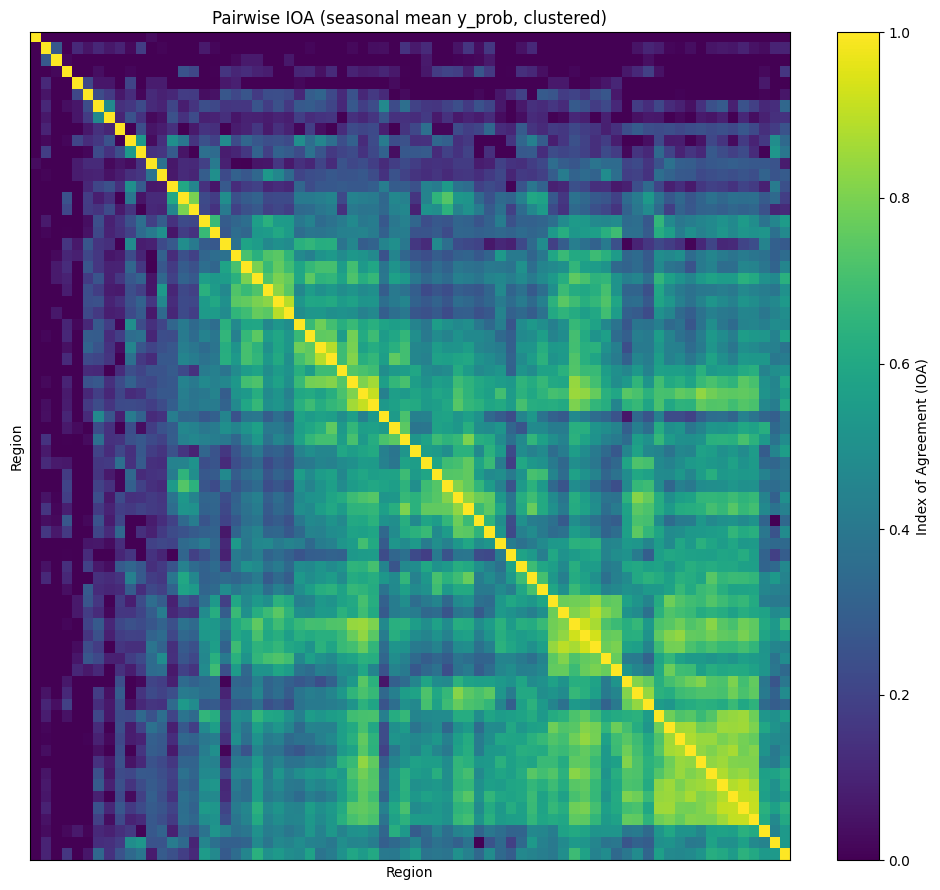

In [28]:
# monthly
Ym, regions, regions_columns, regions_wide = aggregate_region_time(
    full, value_col="y_prob", how="M", agg="mean"
)
# ioa_m = pairwise_ioa_matrix(Ym, regions, symmetrize="mean")
# Y_m is your windowed matrix, e.g. monthly bins with year preserved
# wide_m, Y_m, regions, col_idx = aggregate_region_windows(..., window="month")
corr_df = corr_similarity_matrix(Ym, regions)

ioa_m_ord, order, Z = reorder_by_hclust(corr_df, method="average")
plot_heatmap(ioa_m_ord, title="Pairwise IOA (seasonal mean y_prob, clustered)", show_labels=False)

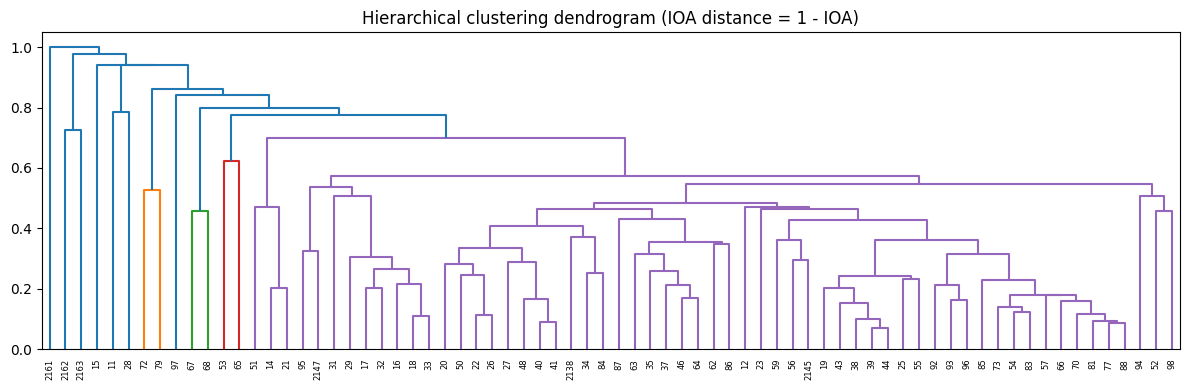

In [30]:
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, labels=corr_df.index.to_list(), leaf_rotation=90, ax=ax)
ax.set_title("Hierarchical clustering dendrogram (IOA distance = 1 - IOA)")
plt.tight_layout()
plt.show()

In [34]:
import numpy as np


def hclust_from_similarity(S_df, method="average"):
    S = S_df.to_numpy(dtype=float)
    D = 1.0 - np.clip(S, -1.0, 1.0)
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=method)
    order = leaves_list(Z)
    return Z, order


Z, order = hclust_from_similarity(corr_df, method="average")

# cluster cut: pick k or pick a distance threshold
k = 6
# cluster_ids = fcluster(Z, t=k, criterion="maxclust")     # k clusters
# or:
cluster_ids = fcluster(Z, t=0.8, criterion="distance")  # distance threshold

cluster_map = pd.Series(cluster_ids, index=corr_df.index, name="cluster")
print(cluster_map.value_counts().sort_index())

cluster
1     2
2     2
3    61
4     1
5     1
6     2
7     2
8     1
Name: count, dtype: int64


In [75]:
k = 10
cluster_map, Z = cut_clusters_from_similarity(ioa_df, k=k, method="average")

# quick look: sizes
print(cluster_map.value_counts().sort_index())


def monthly_cluster_stats(full: pd.DataFrame, cluster_map: pd.Series, value_col="y_prob"):
    """
    full: indexed by ['region','date'] with column value_col
    cluster_map: pd.Series region->cluster (1..k)
    returns a tidy DataFrame:
      month, cluster, mean, std, n_regions
    """
    df = full.reset_index()[["region", "date", value_col]].copy()
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()  # month start timestamp

    # attach cluster id
    df["cluster"] = df["region"].map(cluster_map)

    # monthly mean per region
    reg_month = (
        df.groupby(["cluster", "region", "month"], sort=True)[value_col]
        .mean()
        .rename("region_month_mean")
        .reset_index()
    )

    # aggregate across regions within each cluster-month
    out = (
        reg_month.groupby(["cluster", "month"], sort=True)["region_month_mean"]
        .agg(mean="mean", std="std", n_regions="count")
        .reset_index()
        .sort_values(["cluster", "month"])
    )
    return out


cl_month = monthly_cluster_stats(full, cluster_map, value_col="y_prob")
cl_month.head()

cluster
1      2
2      2
3     61
4      1
5      1
6      1
7      1
8      1
9      1
10     1
Name: count, dtype: int64


,cluster,month,mean,std,n_regions
0,1,2018-02-01,0.000466,0.000539,2
1,1,2018-03-01,0.060878,0.085989,2
2,1,2018-04-01,0.041512,0.058544,2
3,1,2018-05-01,0.004057,0.005614,2
4,1,2018-06-01,0.006627,0.009263,2


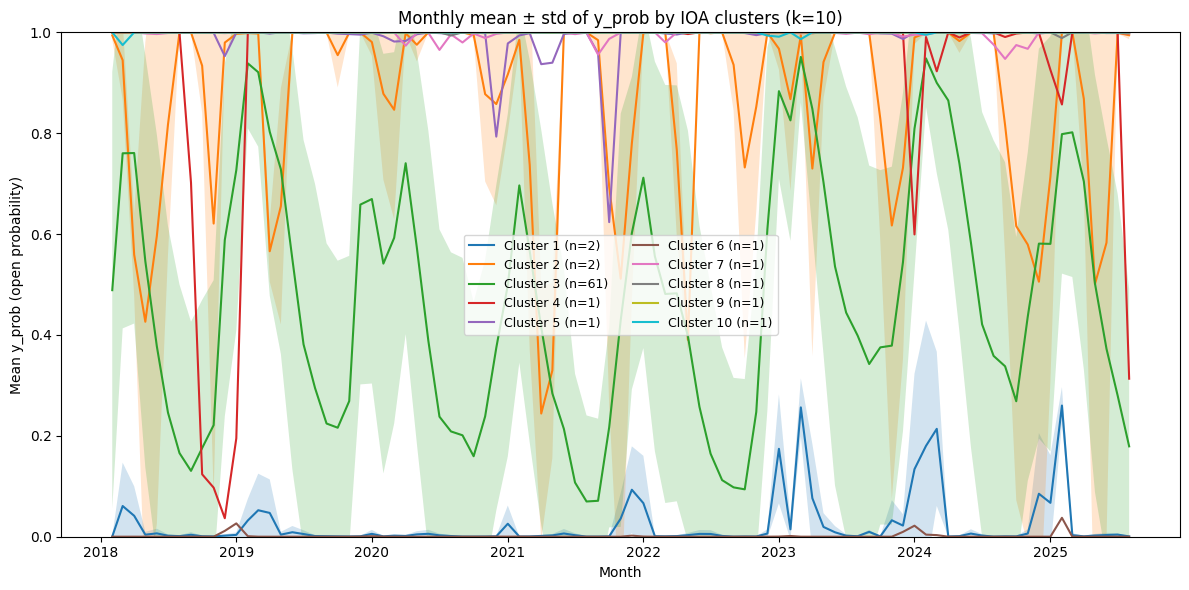

In [69]:
import matplotlib.pyplot as plt


def plot_cluster_monthly_mean_std(
    cl_month: pd.DataFrame, title="Monthly open probability by cluster"
):
    """
    cl_month columns: cluster, month, mean, std, n_regions
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    for cluster_id, g in cl_month.groupby("cluster"):
        g = g.sort_values("month")
        x = g["month"].to_numpy()
        y = g["mean"].to_numpy()
        s = g["std"].fillna(0.0).to_numpy()

        ax.plot(x, y, label=f"Cluster {cluster_id} (n={int(g['n_regions'].max())})")
        ax.fill_between(x, y - s, y + s, alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean y_prob (open probability)")
    ax.set_ylim(0, 1)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


plot_cluster_monthly_mean_std(
    cl_month, title=f"Monthly mean ± std of y_prob by IOA clusters (k={k})"
)

In [42]:
def compute_run_lengths(series: pd.Series):
    """
    Given a binary series (0/1), return lists of run lengths for open (1) and closed (0),
    after filtering out runs shorter than `min_len`.
    """
    arr = series.to_numpy()

    # identify boundaries
    diff = np.diff(arr)
    idx_change = np.where(diff != 0)[0] + 1

    # segment boundaries (include start & end)
    boundaries = np.concatenate(([0], idx_change, [len(arr)]))

    open_runs = []
    closed_runs = []

    # iterate over runs
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        value = arr[start]
        length = end - start

        if value == 1:
            open_runs.append(length)
        else:
            closed_runs.append(length)

    return open_runs, closed_runs

In [61]:
wide = full["y_pred_smooth"].unstack("date").astype(int)
# rows = region, columns = daily dates

region_stats = []
region_stats_year = []

for region, row in wide.iterrows():
    # smooth_row = smooth_short_runs(row.copy(), min_len=3)
    open_runs, closed_runs = compute_run_lengths(row.copy())

    region_stats.append(
        {
            "region": region,
            "mean_open_duration": np.mean(open_runs) if open_runs else np.nan,
            "mean_closed_duration": np.mean(closed_runs) if closed_runs else np.nan,
            "n_open_events": len(open_runs),
            "n_closed_events": len(closed_runs),
            "n_events": len(open_runs) + len(closed_runs),
            "pct_open": row.mean(),
            "n_samples": (
                (preds_all.region == region)
                & (preds_all.date.between(region_min_date.date(), region_max_date.date()))
            ).sum(),
        }
    )

    for year in range(2017, 2026):
        start = pd.Timestamp(year=year, month=10, day=1)
        end = pd.Timestamp(year=year + 1, month=10, day=1)
        mask = row.index.to_series().between(start, end)
        if not mask.sum():
            continue
        y_row = row[mask]
        open_runs, closed_runs = compute_run_lengths(y_row)

        region_stats_year.append(
            {
                "region": region,
                "year": year,
                "mean_open_duration": np.mean(open_runs) if open_runs else np.nan,
                "mean_closed_duration": np.mean(closed_runs) if closed_runs else np.nan,
                "n_open_events": len(open_runs),
                "n_closed_events": len(closed_runs),
                "n_events": len(open_runs) + len(closed_runs),
                "pct_open": y_row.mean(),
                "n_samples": (
                    (preds_all.region == region)
                    & (preds_all.date.between(start.date(), end.date()))
                ).sum(),
            }
        )


duration_df = pd.DataFrame(region_stats).sort_values("region").set_index("region")
duration_gdf = gpd.GeoDataFrame(duration_df.join(gdf), geometry="geometry")

duration_y_df = (
    pd.DataFrame(region_stats_year).sort_values(["region", "year"]).set_index(["region", "year"])
)
duration_y_gdf = gpd.GeoDataFrame(duration_y_df.join(gdf), geometry="geometry")

duration_gdf.head()

,mean_open_duration,mean_closed_duration,n_open_events,n_closed_events,n_events,pct_open,n_samples,Site code,Site name,geometry
region,,,,,,,,,,
11,144.222222,9.000000,18,17,35,0.944343,1039,11.0,Los Penasquitos Lagoon,"POLYGON ((-117.25816 32.93218, -117.25817 32.9..."
12,32.513514,41.783784,37,37,74,0.437614,1064,12.0,Buena Vista Lagoon,"POLYGON ((-117.35532 33.16208, -117.35535 33.1..."
14,121.277778,31.444444,18,18,36,0.794107,1095,14.0,San Luis Rey River,"POLYGON ((-117.38623 33.19826, -117.38627 33.2..."
15,290.666667,14.777778,9,9,18,0.951619,1061,15.0,Santa Margarita River,"POLYGON ((-117.40524 33.22463, -117.4053 33.23..."
16,14.133333,158.562500,15,16,31,0.077119,1125,16.0,Las Fores Creek,"POLYGON ((-117.45996 33.28668, -117.46 33.2940..."


In [62]:
duration_y_df.head(9)

mean_open_duration  mean_closed_duration  n_open_events  \
region year                                                            
11     2017                52.0              5.333333              4   
       2018               173.5             19.000000              2   
       2019               183.0              1.000000              2   
       2020                50.5             12.600000              6   
       2021                66.0              9.000000              5   
       2022                87.0              6.000000              4   
       2023               367.0                   NaN              1   
       2024               334.0                   NaN              1   
12     2017                77.0             73.500000              1   

             n_closed_events  n_events  pct_open  n_samples  
region year                                                  
11     2017                3         7  0.928571         94  
       2018                1         3  0.948087        137  
       2019                1         3  0.997275        152  
       2020                5        11  0.827869        156  
       2021                4         9  0.901639        158  
       2022                3         7  0.950820        109  
       2023                0         1  1.000000        141  
       2024                0         1  1.000000        113  
12     2017                2         3  0.343750         87

<Axes: xlabel='year'>

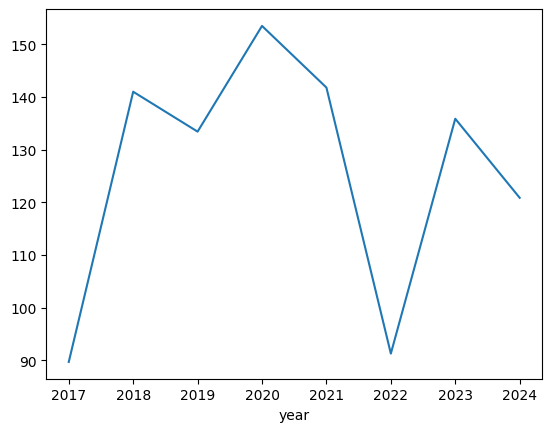

In [63]:
duration_y_df.groupby(level=1).n_samples.mean().plot()

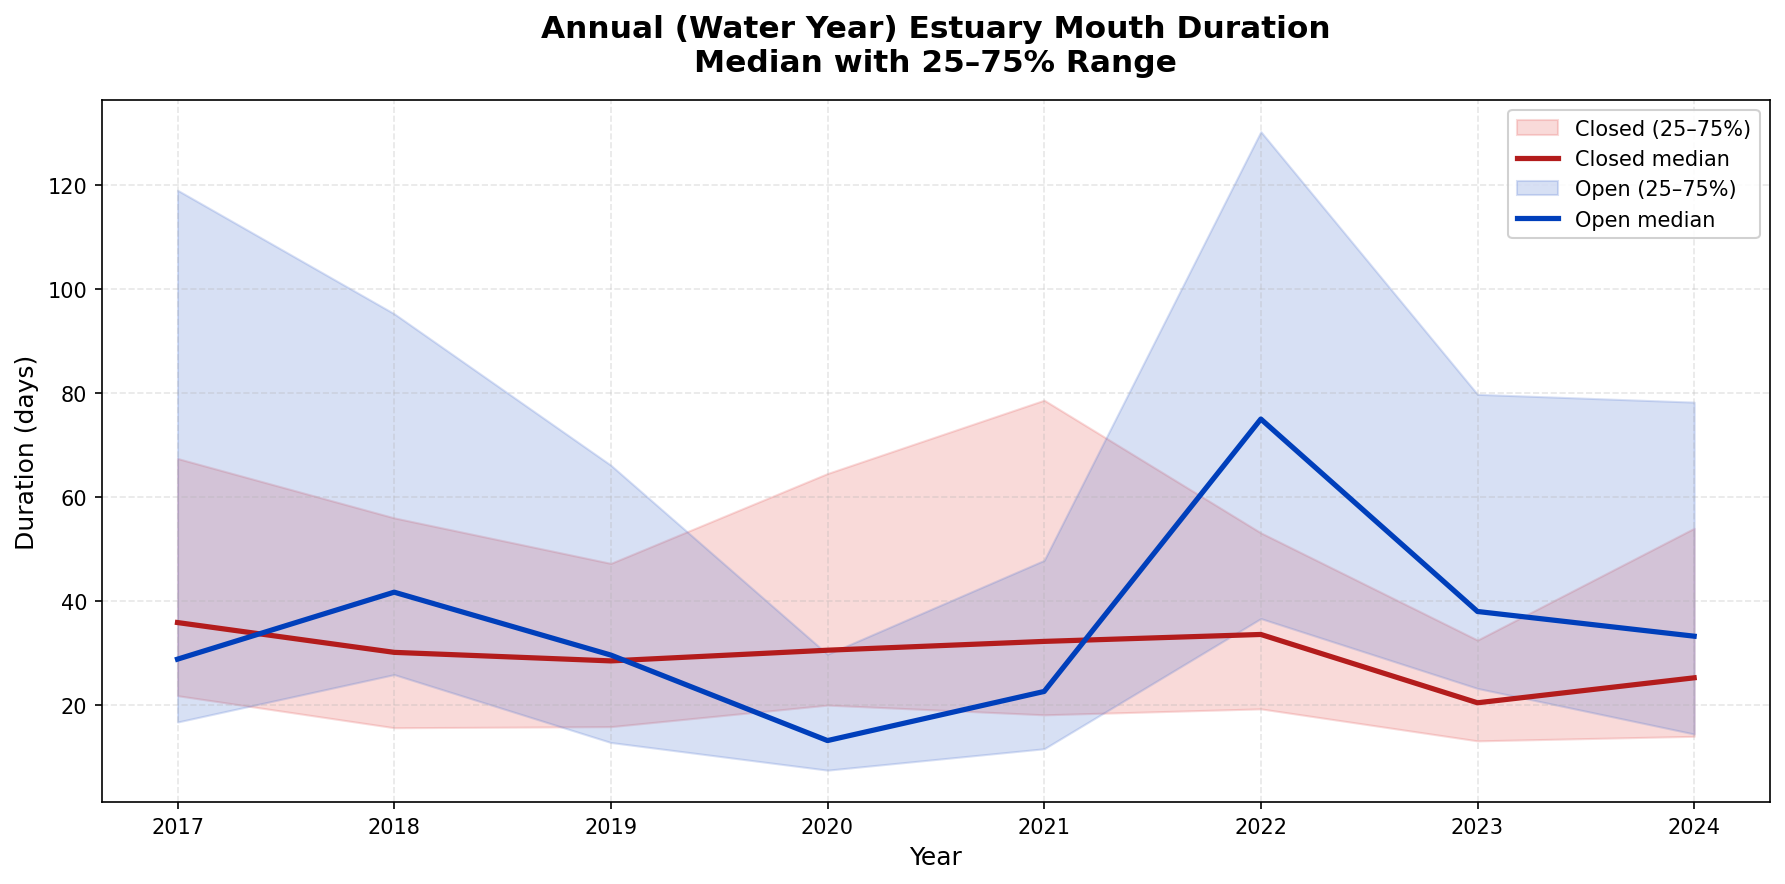

In [224]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Group by year (level=1)
# ---------------------------------------------------------
g = duration_y_df.groupby(level=1)

# Closed duration stats (RED)
closed_q25 = g.mean_closed_duration.quantile(0.25)
closed_med = g.mean_closed_duration.quantile(0.50)
closed_q75 = g.mean_closed_duration.quantile(0.75)

# Open duration stats (BLUE)
open_q25 = g.mean_open_duration.quantile(0.25)
open_med = g.mean_open_duration.quantile(0.50)
open_q75 = g.mean_open_duration.quantile(0.75)

years = closed_med.index

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(12, 6), dpi=150)

# ----- CLOSED (red) -----
plt.fill_between(
    years,
    np.maximum(0, closed_q25),
    closed_q75,
    color="#e45756",
    alpha=0.22,
    label="Closed (25–75%)",
)
plt.plot(
    years,
    closed_med,
    color="#b31c1c",
    lw=2.5,
    label="Closed median",
)

# ----- OPEN (blue) -----
plt.fill_between(
    years,
    np.maximum(0, open_q25),
    open_q75,
    color="#4c72d0",
    alpha=0.22,
    label="Open (25–75%)",
)
plt.plot(
    years,
    open_med,
    color="#003fbb",
    lw=2.5,
    label="Open median",
)

# ---------------------------------------------------------
# Cosmetics
# ---------------------------------------------------------

plt.xlabel("Year", fontsize=12)
plt.ylabel("Duration (days)", fontsize=12)

plt.title(
    "Annual (Water Year) Estuary Mouth Duration\nMedian with 25–75% Range",
    fontsize=15,
    weight="bold",
    pad=14,
)

plt.grid(which="both", alpha=0.3, linestyle="--")

plt.xticks(years, fontsize=10)
plt.yticks(fontsize=10)

# Legend styling
plt.legend(
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="#cccccc",
    fontsize=10,
)

plt.tight_layout()
plt.savefig(FIG_DIR / "yearly_mouth_status_duration.png")
plt.show()

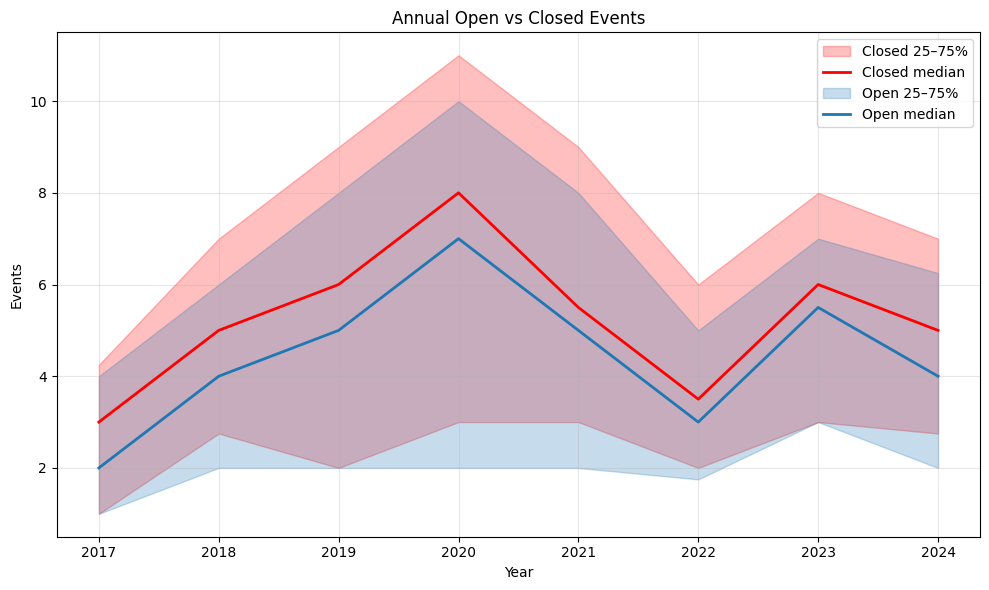

In [71]:
# ---------------------------------------------------------
# Group by year (level=1)
# ---------------------------------------------------------
g = duration_y_df.groupby(level=1)

# Closed duration stats (RED)
q25_closed = g.n_closed_events.quantile(0.25)
q50_closed = g.n_closed_events.quantile(0.50)  # median
q75_closed = g.n_closed_events.quantile(0.75)

# Open duration stats (BLUE)
q25_open = g.n_open_events.quantile(0.25)
q50_open = g.n_open_events.quantile(0.50)  # median
q75_open = g.n_open_events.quantile(0.75)

years = q50_closed.index

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

# ----- CLOSED (red) -----
plt.fill_between(years, q25_closed, q75_closed, color="red", alpha=0.25, label="Closed 25–75%")
plt.plot(years, q50_closed, color="red", lw=2, label="Closed median")

# ----- OPEN (blue) -----
plt.fill_between(years, q25_open, q75_open, color="C0", alpha=0.25, label="Open 25–75%")
plt.plot(years, q50_open, color="C0", lw=2, label="Open median")

plt.xlabel("Year")
plt.ylabel("Events")
plt.title("Annual Open vs Closed Events")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
import matplotlib.pyplot as plt


def df_to_png(df, filename=None):
    fig, ax = plt.subplots(figsize=(df.shape[1], df.shape[0] * 0.4))
    ax.axis("off")

    # Build cell colors
    colors = []
    for i in range(len(df)):
        if i % 2 == 0:
            colors.append(["#ffffff"] * df.shape[1])  # white
        else:
            colors.append(["#f7f7f7"] * df.shape[1])  # light gray

    table = ax.table(
        cellText=df.values, colLabels=df.columns, cellLoc="left", loc="center", cellColours=colors
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.auto_set_column_width(col=list(range(df.shape[1])))

    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.close()

In [83]:
vopen = duration_df[duration_df.pct_open > 0.95][["pct_open"]]
very_open_sites = (
    pd.merge(gdf, vopen, left_index=True, right_index=True)[["Site name", "pct_open"]]
    .sort_values("pct_open")
    .round(3)
)

df_to_png(very_open_sites, FIG_DIR / "very_open_sites.png")

very_open_sites

,Site name,pct_open
region,,
15,Santa Margarita River,0.952
79,Garcia River,0.992
2161,Mugu Lagoon,1.000
2163,Tijuana River Estuary,1.000
2162,San Dieguito Lagoon,1.000
97,Klamath River,1.000


In [78]:
pth = "/Volumes/x10pro/estuary/skysat/results/2022/2163/files/20220206_183407_ssc1_u0001_pansharpened_clip.tif"
with rasterio.open(pth) as src:
    data = src.read()
    nodata = src.read(1, masked=True).mask
    img = Image.fromarray(true_color(data, nodata)).save(FIG_DIR / "2163_example_outlier.png")

In [84]:
vclosed = duration_df[duration_df.pct_open < 0.1][["pct_open"]]
very_closed_sites = (
    pd.merge(gdf, vclosed, left_index=True, right_index=True)[["Site name", "pct_open"]]
    .sort_values("pct_open")
    .round(3)
)

df_to_png(very_closed_sites, FIG_DIR / "very_closed_sites.png")

very_closed_sites

,Site name,pct_open
region,,
53,Younder Lagoon,0.000
65,Abbots Lagoon,0.007
2147,Rodeo Lagoon,0.026
16,Las Fores Creek,0.077
29,NaN,0.077
95,Stone Lagoon,0.095


In [85]:
def extract_events_from_wide(wide):
    """
    Given a region × date wide matrix of 0/1 status,
    return a DataFrame of events: region, start, end, duration, state.
    state = 1 means open, 0 means closed.
    Short runs (< min_duration days) are *merged* into neighbors.
    """
    events = []
    dates = pd.to_datetime(wide.columns)
    wide = wide.copy()
    wide.columns = dates  # ensure DatetimeIndex

    for region, row in wide.iterrows():
        arr = row.values

        # 2) find runs on the cleaned array
        n = len(arr)
        if n == 0:
            continue

        run_starts = np.concatenate([[0], np.where(np.diff(arr) != 0)[0] + 1])
        run_ends = np.concatenate([run_starts[1:] - 1, [n - 1]])

        for start_idx, end_idx in zip(run_starts, run_ends):
            state = int(arr[start_idx])
            assert int(arr[end_idx]) == state
            start_date = dates[start_idx]
            end_date = dates[end_idx]
            duration = (end_date - start_date).days + 1

            events.append(
                {
                    "region": region,
                    "state": int(state),  # 1=open, 0=closed
                    "start": start_date,
                    "end": end_date,
                    "end_month": end_date.month,
                    "duration_days": duration,
                }
            )

    return pd.DataFrame(events)

In [86]:
wide = full["y_pred_smooth"].unstack("date").astype(int)
events_df = extract_events_from_wide(wide)

# -------------------------------------------------------------------
# 3. Filter by season
#    Define summer/winter by month (you can adjust)
# -------------------------------------------------------------------
summer_months = [6, 7, 8, 9]  # Jun–Sep
winter_months = [12, 1, 2]  # Dec–March

# Opening events in summer
summer_open_events = events_df[(events_df.end_month.isin(summer_months)) & (events_df.state == 0)]

# Closing events in winter
winter_close_events = events_df[(events_df.end_month.isin(winter_months)) & (events_df.state == 1)]

# Optional: get counts by region
summer_open_counts = pd.merge(
    summer_open_events.groupby("region").size().to_frame(name="event_count"),
    gdf[["Site name"]],
    left_index=True,
    right_index=True,
)
winter_close_counts = pd.merge(
    winter_close_events.groupby("region").size().to_frame(name="event_count"),
    gdf[["Site name"]],
    left_index=True,
    right_index=True,
)

print("Summer openings per region:")
print(summer_open_counts.sort_values("event_count", ascending=False))

print("\nWinter closings per region:")
print(winter_close_counts.sort_values("event_count", ascending=False))

Summer openings per region:
        event_count               Site name
region                                     
92               45         Mattolle River 
87               32         Cottaneva Creek
52               31                    None
56               31       San Lorenzo River
93               28              Bear River
...             ...                     ...
68                1        Estero Americano
67                1  Estereo De San Antonio
65                1           Abbots Lagoon
57                1            Soquel Creek
2147              1            Rodeo Lagoon

[66 rows x 2 columns]

Winter closings per region:
        event_count               Site name
region                                     
55               26             Rio Del Mar
43               24                     NaN
85               24           Pudding Creek
26               24             Bell Canyon
52               23                    None
...             ...                     

region                            12
state                              0
start            2021-06-05 00:00:00
end              2021-06-22 00:00:00
end_month                          6
duration_days                     18
Name: 63, dtype: object


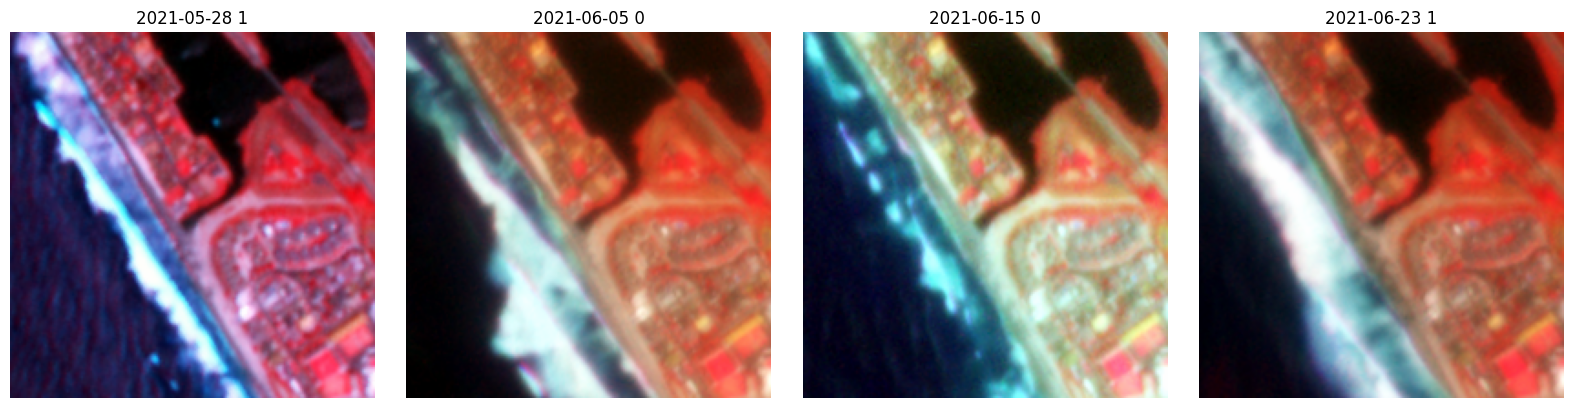

In [89]:
region = 12
idx = 1
state = 0
months = summer_months

dt_row = events_df[
    (events_df.region == region) & (events_df.state == state) & (events_df.end_month.isin(months))
].iloc[idx]
print(dt_row)
before = preds_all[(preds_all.region == region) & (preds_all.acquired < dt_row.start)].iloc[-1]
start = preds_all[(preds_all.region == region) & (preds_all.acquired >= dt_row.start)].iloc[0]
end = preds_all[(preds_all.region == region) & (preds_all.acquired <= dt_row.end)].iloc[-1]
after = preds_all[(preds_all.region == region) & (preds_all.acquired > dt_row.end)].iloc[0]

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

row = before
# print(row)
with rasterio.open(row.source_tif) as src:
    data = src.read()
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"{row.date} {row.y_pred_smooth}")

row = start
# print(row)
with rasterio.open(row.source_tif) as src:
    data = src.read()
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)
    axes[1].imshow(img)
    axes[1].axis("off")
    axes[1].set_title(f"{row.date} {row.y_pred_smooth}")

row = end
# print(row)
with rasterio.open(row.source_tif) as src:
    data = src.read()
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)
    axes[2].imshow(img)
    axes[2].axis("off")
    axes[2].set_title(f"{row.date} {row.y_pred_smooth}")

row = after
# print(row)
with rasterio.open(row.source_tif) as src:
    data = src.read()
    nodata = src.read(1, masked=True).mask
    img = false_color(data, nodata)
    axes[3].imshow(img)
    axes[3].axis("off")
    axes[3].set_title(f"{row.date} {row.y_pred_smooth}")

fig.tight_layout()

In [92]:
import numpy as np
import pandas as pd


def detect_multi_estuary_changes_clusters(events_df, state, window_days=3, min_sites=10):
    """
    Detect windows where at least `min_sites` distinct estuaries
    have an opening event (state==1) within `window_days` of each other.

    Parameters
    ----------
    events_df : DataFrame
        Must contain at least ['region', 'state', 'start'].
        state == 1 means open-event.
    window_days : int
        Length of the time window (in days). Inclusive.
    min_sites : int
        Minimum number of *distinct regions* with an opening
        in that window to count as a cluster.

    Returns
    -------
    clusters_df : DataFrame
        Columns:
            - window_start
            - window_end
            - n_regions      (distinct regions)
            - regions        (list of regions)
            - n_events       (total opening events in window)
    """

    # Filter to opening events only
    opens = events_df[events_df["state"] == state].copy()
    if opens.empty:
        return pd.DataFrame(
            columns=["window_start", "window_end", "n_regions", "regions", "n_events"]
        )

    # Ensure datetime and sort by start time
    opens["start"] = pd.to_datetime(opens["start"])
    opens = opens.sort_values("start").reset_index(drop=True)

    dates = opens["start"].values.astype("datetime64[ns]")  # numpy datetime array
    days = pd.to_datetime(opens["start"].dt.date.unique())
    regions = opens["region"].to_numpy()

    clusters = []
    n = len(days)
    j = 0

    # Two-pointer sliding window
    for d in days:
        de = d + np.timedelta64(window_days, "D")
        window_idx = [idx for idx, date in enumerate(dates) if date >= d and date <= de]
        # # Advance j while events are within window_days of opens[i]
        # while j < n and (dates[j] - dates[i]) <= np.timedelta64(window_days, "D"):
        #     j += 1

        # # Events in [i, j)
        # window_idx = range(i, j)
        window_regions = set(regions[k] for k in window_idx)
        n_regions = len(window_regions)
        i = window_idx[0]
        j = window_idx[-1]

        if n_regions >= min_sites:
            window_start = dates[i]
            window_end = dates[j]

            clusters.append(
                {
                    "window_start": pd.Timestamp(window_start),
                    "window_end": pd.Timestamp(window_end),
                    "n_regions": n_regions,
                    "regions": sorted(window_regions),
                    "n_events": len(window_idx),
                }
            )

    clusters_df = pd.DataFrame(clusters)

    # Optional: drop exact duplicate windows (can happen with overlapping i)
    if not clusters_df.empty:
        clusters_df = clusters_df.drop_duplicates(
            subset=["window_start", "window_end", "n_regions"]
        ).reset_index(drop=True)

    clusters_df = (
        clusters_df.sort_values(["window_end", "n_events"], ascending=False)
        .drop_duplicates("window_end")
        .sort_values("window_start")
    )

    return clusters_df


clusters_df = detect_multi_estuary_changes_clusters(
    events_df,
    state=0,
    window_days=5,  # N
    min_sites=20,  # M
).iloc[1:]

clusters_df

,window_start,window_end,n_regions,regions,n_events
1,2018-12-08,2018-12-13,23,"[15, 18, 22, 25, 26, 34, 38, 39, 40, 44, 51, 5...",24
2,2018-12-10,2018-12-15,20,"[18, 22, 25, 26, 38, 39, 40, 44, 51, 55, 59, 6...",20
3,2018-12-11,2018-12-16,20,"[18, 20, 22, 25, 26, 38, 39, 40, 44, 51, 55, 5...",20
4,2021-01-14,2021-01-19,24,"[16, 19, 22, 26, 27, 29, 31, 38, 39, 40, 41, 4...",25
5,2021-01-15,2021-01-20,23,"[16, 19, 22, 26, 27, 28, 29, 38, 39, 40, 41, 4...",23
6,2021-01-16,2021-01-21,21,"[19, 26, 28, 38, 39, 40, 41, 43, 44, 46, 51, 5...",21
7,2023-10-20,2023-10-25,23,"[22, 27, 28, 31, 32, 33, 34, 41, 44, 46, 48, 5...",23
8,2023-10-21,2023-10-26,25,"[22, 27, 28, 31, 32, 33, 34, 41, 44, 46, 48, 5...",25
9,2023-10-23,2023-10-28,25,"[20, 31, 34, 39, 40, 41, 44, 46, 48, 54, 55, 5...",27
10,2023-11-25,2023-11-30,21,"[22, 28, 34, 35, 38, 39, 40, 41, 43, 44, 54, 5...",23


In [233]:
def compute_first_transition_stats(
    wide: pd.DataFrame,
    years: range,
    start_month: int,
    kind: str = "open",
    start_day: int = 1,
):
    """
    Compute first OPEN or CLOSE time per water-year and region.

    Parameters
    ----------
    wide : DataFrame
        Rows = regions, columns = dates (datetime), values = 0/1 (closed/open).
    years : range
        Range of water-year labels (e.g., range(2018, 2025)).
    start_month : int
        Month that defines the water-year start (e.g., 10 for Oct, 4 for Apr).
    kind : {'open', 'close'}
        'open'  -> first 0->1 transition
        'close' -> first 1->0 transition
    start_day : int
        Day of month for water-year start (default 1).

    Returns
    -------
    stats : DataFrame indexed by water_year
        Columns: ['mean_offset', 'std_offset']
    events : DataFrame
        Per-region data with columns:
        ['region', 'water_year', 'first_event_date', 'offset_days']
    """
    assert kind in {"open", "close"}
    # Ensure datetime columns
    wide = wide.copy()
    wide.columns = pd.to_datetime(wide.columns)

    rows = []

    for water_year in years:
        wy_start = pd.Timestamp(year=water_year, month=start_month, day=start_day)
        wy_end = pd.Timestamp(year=water_year + 1, month=start_month, day=start_day)

        col_mask = (wide.columns >= wy_start) & (wide.columns < wy_end)
        if not col_mask.any():
            continue

        dates_wy = wide.columns[col_mask]
        wide_y = wide.loc[:, col_mask]

        for region, row in wide_y.iterrows():
            arr = row.values.astype(int)

            if kind == "open":
                # first 0->1 (treat day before window as closed)
                if np.all(arr == 1):
                    continue
                # prev = np.r_[0, arr[:-1]]
                idx = np.where(arr == 1)[0]
            else:  # kind == "close"
                # first 1->0 (requires previous day open)
                if np.all(arr == 0):
                    continue
                # prev = np.r_[arr[0], arr[:-1]]
                idx = np.where(arr == 0)[0]

            if len(idx):
                first_date = dates_wy[idx[0]]
                offset = (first_date - wy_start).days
            else:
                first_date = pd.NaT
                offset = np.nan

            rows.append(
                {
                    "region": region,
                    "water_year": water_year,
                    "first_event_date": first_date,
                    "offset_days": offset,
                }
            )

    events = pd.DataFrame(rows)

    # Keep only valid offsets for stats
    valid = events.dropna(subset=["offset_days"])

    stats = (
        valid.groupby("water_year")["offset_days"]
        .quantile([0.25, 0.5, 0.75])
        .unstack()
        .rename(columns={0.25: "q25", 0.5: "q50", 0.75: "q75"})
    )

    return stats, events


def set_monthy_axis(ax, start_month: int, label_prefix: str, last_month: int):
    ref_year = 2020
    wy_start_ref = pd.Timestamp(year=ref_year, month=start_month, day=1)
    month_starts = pd.date_range(wy_start_ref, wy_start_ref + pd.DateOffset(years=1), freq="MS")[
        :-1
    ][:last_month]

    yticks = [(d - wy_start_ref).days for d in month_starts]
    ylabels = [d.strftime("%b") for d in month_starts]

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_ylabel(f"{label_prefix} (months since {wy_start_ref.strftime('%b 1')})")


wide = full["y_pred_smooth"].unstack("date").astype(int)

years = range(2018, 2025)

# First OPEN per Oct–Oct water year
open_stats, open_events = compute_first_transition_stats(
    wide=wide,
    years=years,
    start_month=10,  # October
    kind="open",
)

# First CLOSE per Apr–Apr “closing season”
close_stats, close_events = compute_first_transition_stats(
    wide=wide,
    years=years,
    start_month=3,
    kind="close",
)

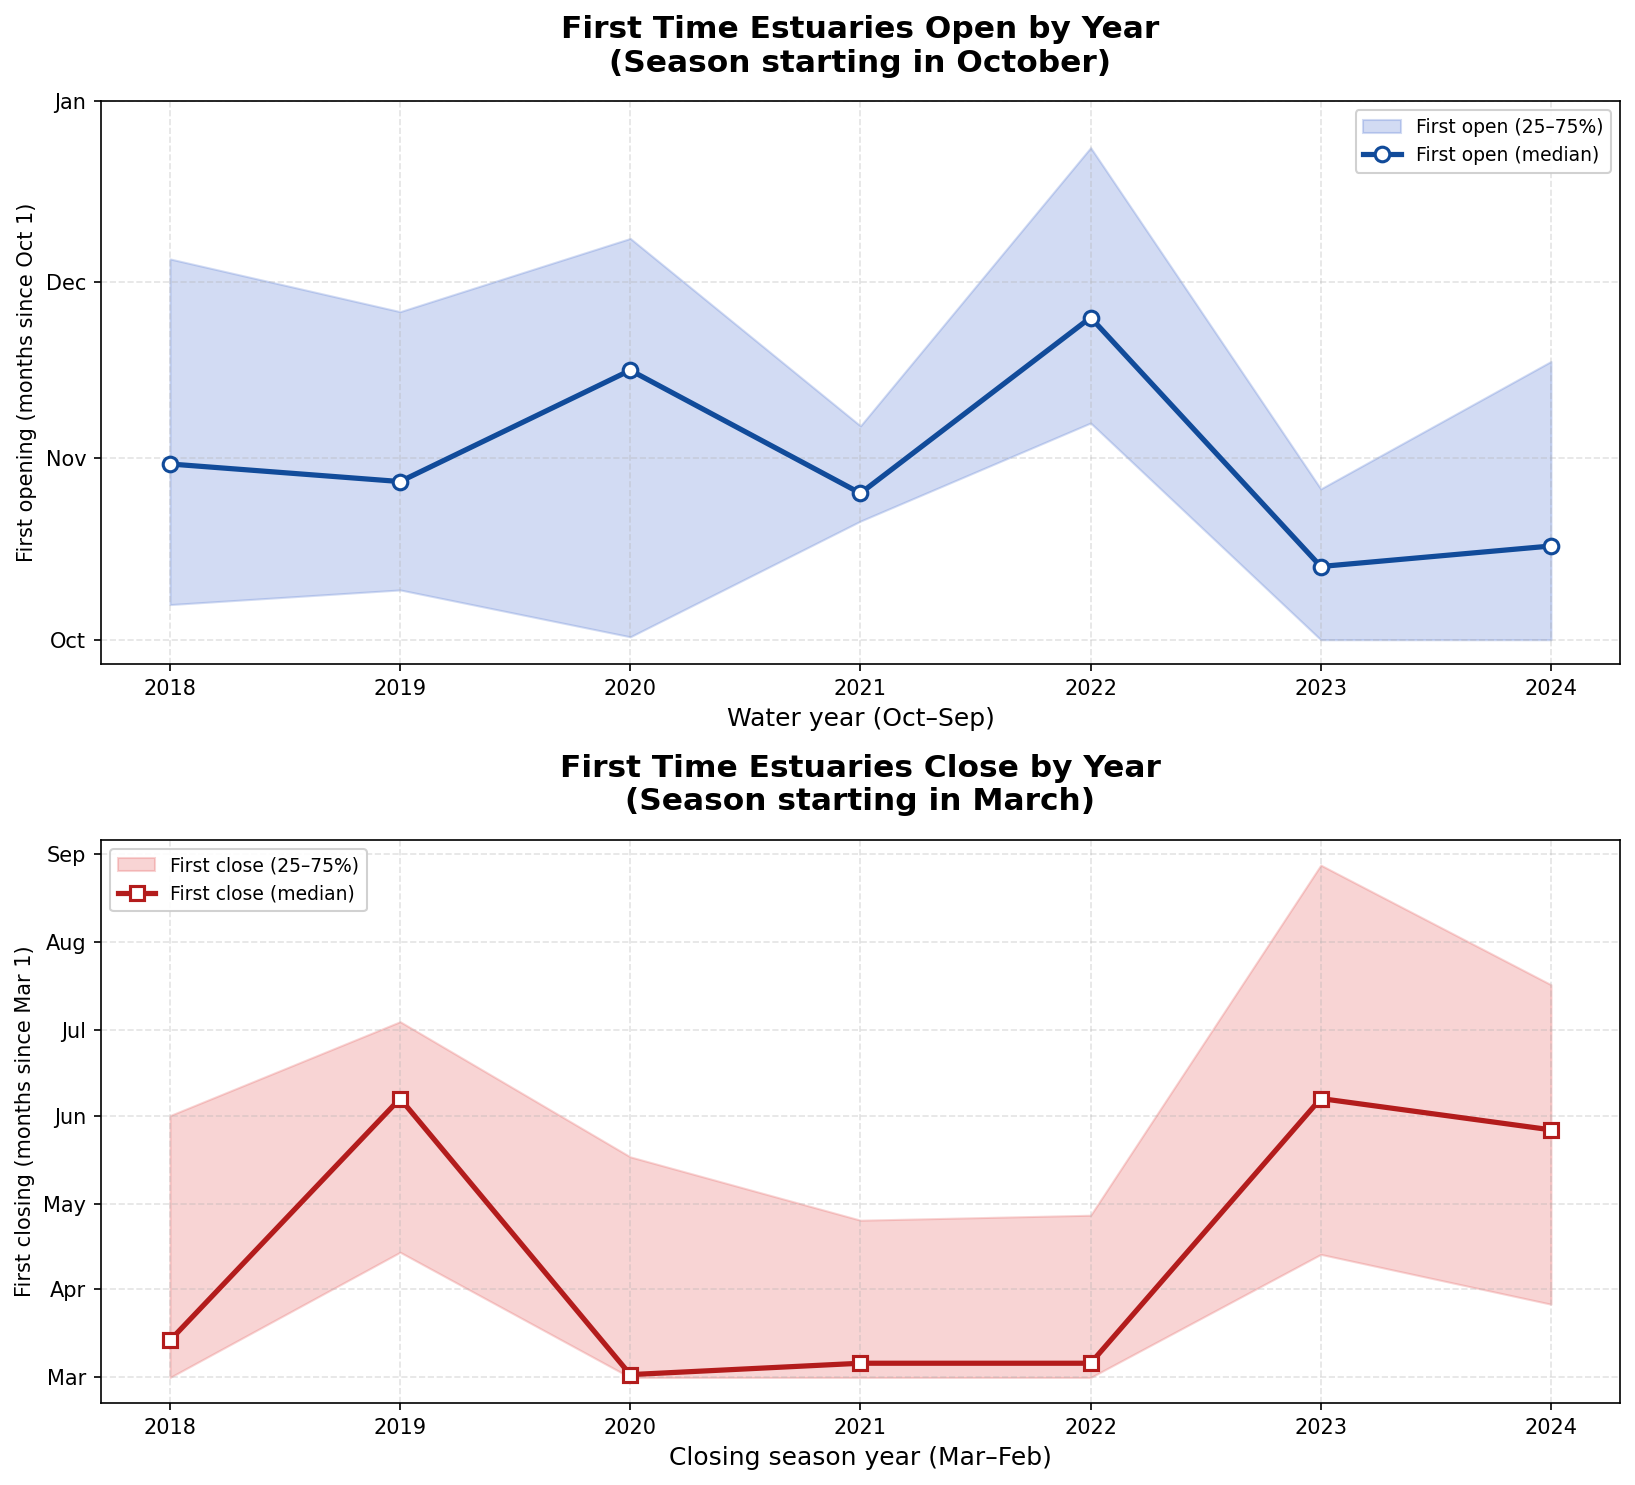

In [234]:
import matplotlib.pyplot as plt

# Make sure stats indices align with years list
open_stats = open_stats.reindex(list(years))
close_stats = close_stats.reindex(list(years))

# -----------------------------
# Plot 1: First opening timing
# -----------------------------
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(11, 10), dpi=150)

axes[0].fill_between(
    open_stats.index,
    open_stats["q25"],
    open_stats["q75"],
    color="#4c72d0",
    alpha=0.25,
    label="First open (25–75%)",
)

axes[0].plot(
    open_stats.index,
    open_stats["q50"],
    color="#114b9a",
    lw=2.5,
    marker="o",
    markersize=7,
    markerfacecolor="white",
    markeredgewidth=1.5,
    label="First open (median)",
)

set_monthy_axis(axes[0], start_month=10, label_prefix="First opening", last_month=4)

axes[0].set_xlabel("Water year (Oct–Sep)", fontsize=12)
axes[0].set_title(
    "First Time Estuaries Open by Year\n(Season starting in October)",
    fontsize=15,
    weight="bold",
    pad=14,
)
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].legend(
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="#cccccc",
    fontsize=9,
)

# -----------------------------
# Plot 2: First closing timing
# -----------------------------
axes[1].fill_between(
    close_stats.index,
    close_stats["q25"],
    close_stats["q75"],
    color="#e45756",
    alpha=0.25,
    label="First close (25–75%)",
)

axes[1].plot(
    close_stats.index,
    close_stats["q50"],
    color="#b31c1c",
    lw=2.5,
    marker="s",
    markersize=7,
    markerfacecolor="white",
    markeredgewidth=1.5,
    label="First close (median)",
)

set_monthy_axis(axes[1], start_month=3, label_prefix="First closing", last_month=7)

axes[1].set_xlabel("Closing season year (Mar–Feb)", fontsize=12)
axes[1].set_title(
    "First Time Estuaries Close by Year\n(Season starting in March)",
    fontsize=15,
    weight="bold",
    pad=14,
)
axes[1].grid(True, linestyle="--", alpha=0.35)
axes[1].legend(
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="#cccccc",
    fontsize=9,
)

fig.tight_layout()
plt.savefig(FIG_DIR / "first_open_close.png")
plt.show()

In [143]:
def plot_col(pp_gdf, column):
    color_scale = linear.viridis.scale(
        duration_gdf[duration_gdf.n_open_events > 1][column].min(),
        duration_gdf[duration_gdf.n_closed_events > 1][column].max(),
    )

    # Initialize map centered on all data
    bounds = duration_gdf.total_bounds  # [minx, miny, maxx, maxy]
    m = folium.Map(
        location=[(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2],
        zoom_start=6,
        tiles="CartoDB positron",
        width=700,
        height=500,
    )

    # Add sites (one color)
    for region, row in duration_gdf.iterrows():
        if pd.isna(row[column]):
            color = "grey"
        else:
            color = color_scale(row[column])
        folium.CircleMarker(
            location=[row.geometry.centroid.y, row.geometry.centroid.x],
            radius=6,
            color=None,
            fill_opacity=0.9,
            fill=True,
            fill_color=color,
            popup=f"Site: {region} {column}: {row[column]:.2f}",
        ).add_to(m)

    return m

In [144]:
plot_col(duration_gdf, "mean_open_duration")

In [145]:
plot_col(duration_gdf, "mean_closed_duration")

In [151]:
plot_col(duration_gdf, "n_closed_events")

In [147]:
plot_col(duration_gdf, "n_open_events")

In [148]:
plot_col(duration_gdf, "n_events")

In [149]:
plot_col(duration_gdf, "n_samples")

In [150]:
plot_col(duration_gdf, "pct_open")

In [152]:
# ---------------------------------------------------------------------
# 1. Build continuous probability matrix with temporal smoothing
# ---------------------------------------------------------------------


def build_prob_matrix(df, smooth_window=7, center=True):
    """
    Build a (n_regions x n_days) matrix of smoothed open probability.

    Parameters
    ----------
    df : DataFrame
        Columns: ['region', 'date', 'y_prob', ...]
    smooth_window : int
        Rolling window size in days for temporal smoothing.
    center : bool
        Whether to center the rolling window.

    Returns
    -------
    prob_matrix : np.ndarray of shape (n_regions, n_days)
        Smoothed probabilities in [0,1].
    regions : list of str
        Region labels in row order.
    dates : DatetimeIndex
        Dates in column order.
    """

    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    # Global date range
    start_date = df["date"].min().normalize()
    end_date = df["date"].max().normalize()
    all_dates = pd.date_range(start_date, end_date, freq="D")

    regions_lat = list(zip(gdf.geometry.bounds.miny, gdf.index))
    regions = [r for _, r in sorted(regions_lat)]
    n_regions = len(regions)
    n_days = len(all_dates)

    prob_matrix = np.zeros((n_regions, n_days), dtype=float)

    for i, region in enumerate(regions):
        sdf = df[df["region"] == region].copy()
        sdf = sdf.sort_values("date")

        sdf = sdf.set_index("date")[["y_prob"]]

        # Reindex to full date range
        sdf = sdf.reindex(all_dates)

        # Fill missing:
        #   1) interpolate in time where possible
        #   2) then forward-fill
        #   3) remaining NaNs (before first obs) set to 0 (assume closed)
        sdf["y_prob"] = (
            sdf["y_prob"].interpolate(method="time", limit_direction="both").ffill().fillna(0.0)
        )

        # Temporal smoothing with rolling mean
        sdf["y_prob_smooth"] = (
            sdf["y_prob"].rolling(window=smooth_window, center=center, min_periods=1).mean()
        )

        prob_matrix[i, :] = sdf["y_prob_smooth"].to_numpy()

    # Clip to [0,1] just in case of numerical weirdness
    prob_matrix = np.clip(prob_matrix, 0.0, 1.0)

    return prob_matrix, regions, all_dates


# ---------------------------------------------------------------------
# 2. Plot raster of smoothed probabilities
# ---------------------------------------------------------------------


def plot_prob_raster(prob_matrix, regions, dates, figsize=(14, 10), title=None):
    """
    Plot estuary open probability as a raster (regions x dates).
    """
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        prob_matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
        extent=[0, prob_matrix.shape[1], 0, prob_matrix.shape[0]],
        vmin=0.0,
        vmax=1.0,
    )

    # Y axis labels
    ax.set_yticks(np.arange(len(regions)) + 0.5)
    ax.set_yticklabels(regions)

    # X axis date ticks
    n_days = len(dates)
    tick_positions = np.linspace(0, n_days, 10, endpoint=False, dtype=int)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels(
        [dates[i].strftime("%Y-%m-%d") for i in tick_positions],
        rotation=45,
        ha="right",
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Estuary (region)")

    if title is None:
        title = "Smoothed estuary mouth open probability"
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, label="Open probability")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 3. Optional: yearly mean openness using probabilities
# ---------------------------------------------------------------------


def plot_yearly_mean_prob(prob_matrix, dates, figsize=(8, 4), title=None):
    """
    For each year, compute mean open probability across
    all regions and days and plot as a time series.
    """
    flat = pd.DataFrame(
        prob_matrix.T,  # days x regions
        index=dates,
        columns=[f"r{i}" for i in range(prob_matrix.shape[0])],
    )

    daily_mean_prob = flat.mean(axis=1)
    yearly_mean_prob = daily_mean_prob.groupby(daily_mean_prob.index.year).mean()

    fig, ax = plt.subplots(figsize=figsize)
    yearly_mean_prob.plot(marker="o", ax=ax)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean open probability\n(across regions & days)")
    if title is None:
        title = "Yearly mean estuary openness (probability)"
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return yearly_mean_prob

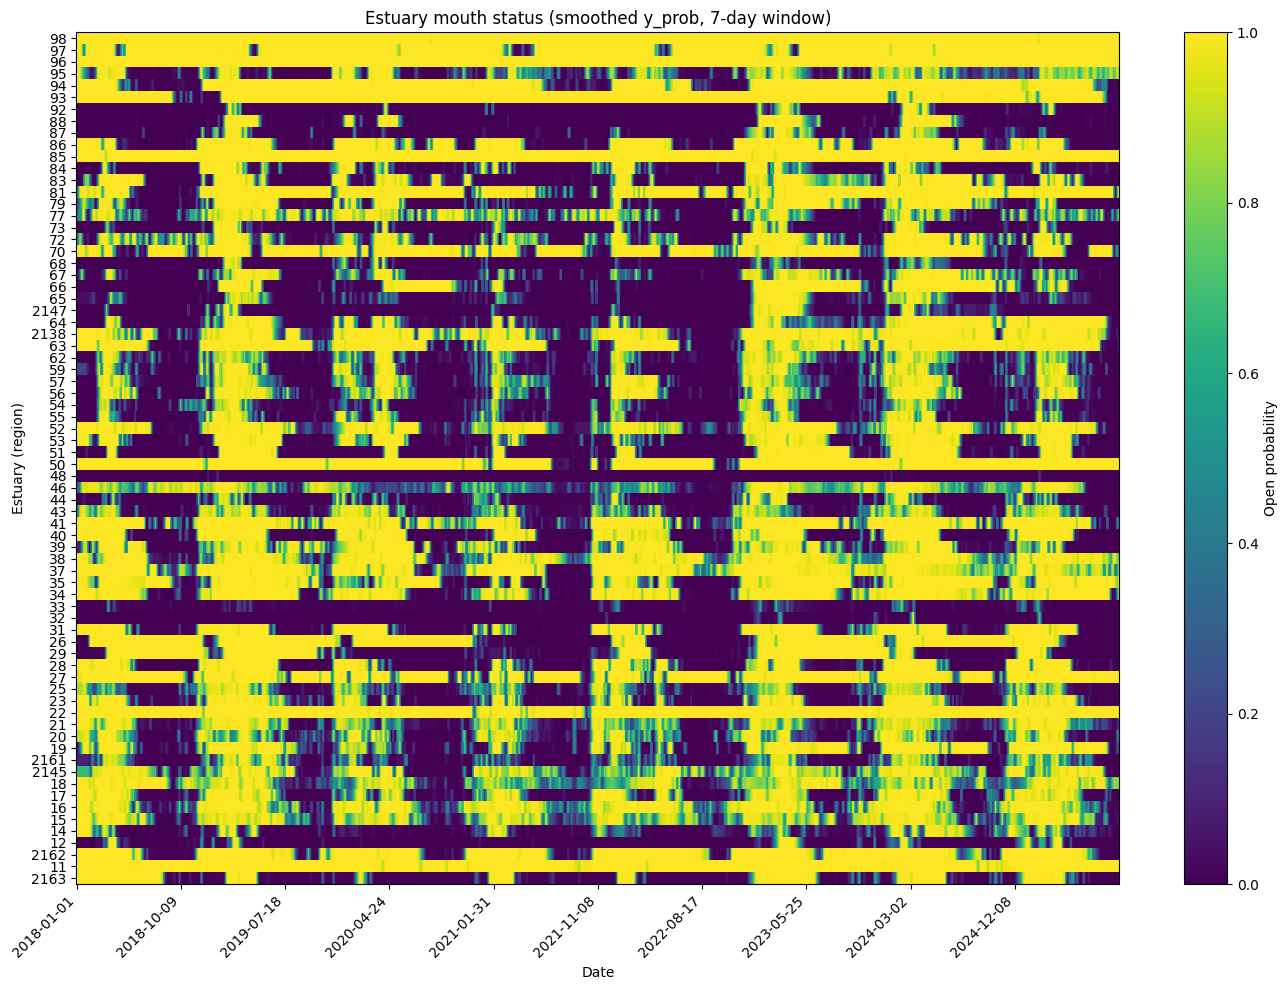

In [153]:
# ---------------------------------------------------------------------
# 4. Example usage
# ---------------------------------------------------------------------

prob_matrix, regions, dates = build_prob_matrix(df, smooth_window=7, center=True)
plot_prob_raster(
    prob_matrix, regions, dates, title="Estuary mouth status (smoothed y_prob, 7-day window)"
)